# Nemotron-Personas-Korea 실습: 불러오기, 기초통계, 직무별로 보기

Hugging Face에 공개된 `nvidia/Nemotron-Personas-Korea`(100만 행, 26개 컬럼, CC BY 4.0)를 받아서 열어 보는 실습이다.

1. 데이터 받기
2. 불러오기와 컬럼 구성
3. 기초통계
4. **직무 관점으로 걸러 보기** (직업명 검색 → 직무 집단 요약 → 전체와 비교 → 서술문 읽기 → 직무끼리 비교)

실행 환경: Python 3.9 이상. 커널은 0절에서 등록하는 **Python 3.9 (nvdia_persona)** 를 고른다.
위에서부터 차례로 실행하면 된다. 직무를 바꿔 보려면 4절의 `JOB_KEYWORDS`만 고쳐서 4절을 다시 실행한다.

코드가 낯설면 <a href="../reports/07_python_basics.html" target="_blank" rel="noopener">이 노트북에 나온 Python 기초 문법 (새 탭)</a>을 옆에 열어 두고 읽는다. pandas가 아니라 polars를 쓴 이유도 거기에 적었다.

## 0. 준비

### 가상환경과 커널

가상환경은 프로젝트마다 따로 쓰는 파이썬 설치본이다. 여기서 설치한 polars 같은 패키지가 다른 프로젝트나 PC 전체의 파이썬과 섞이지 않는다. 아래 네 줄을 터미널(명령 프롬프트)에서 한 번만 실행한다.

| 줄 | 하는 일 |
|---|---|
| 1 | `venv` 도구로 가상환경을 만든다. `%USERPROFILE%`는 `C:\Users\<사용자>`이고, 그 아래 `.venvs`라는 폴더 안에 `nvdia_persona`라는 이름으로 만든다. `.venvs`는 명령어가 아니라 가상환경을 모아 두는 폴더 이름이다. 다른 이름을 써도 된다. |
| 2 | 가상환경을 켠다. 이후 같은 창에서 치는 `python`과 `pip`은 이 환경의 것을 가리키고, 프롬프트 앞에 `(nvdia_persona)`가 붙는다. |
| 3 | 켜진 가상환경 안에만 패키지를 설치한다. |
| 4 | 이 가상환경을 Jupyter 커널로 등록한다. VS Code의 커널 목록에 "Python 3.9 (nvdia_persona)"로 뜬다. |

가상환경은 Dropbox나 OneDrive처럼 동기화되는 폴더 밖에 만든다. 동기화 폴더 안에 두면 파일 잠금 때문에 설치가 도중에 깨질 수 있다. `%USERPROFILE%\.venvs`가 그 밖에 있는 자리다.

```
python -m venv %USERPROFILE%\.venvs\nvdia_persona
%USERPROFILE%\.venvs\nvdia_persona\Scripts\activate
pip install polars matplotlib huggingface_hub python-dotenv pyarrow ipykernel
python -m ipykernel install --user --name nvdia_persona --display-name "Python 3.9 (nvdia_persona)"
```

VS Code에서 이 노트북을 열고 오른쪽 위의 커널 선택에서 **Python 3.9 (nvdia_persona)** 를 고른다. 다른 커널을 고르면 첫 셀에서 `No module named 'polars'` 오류가 난다.

### 설정 파일(.env) 만들기

경로, 시드, 글꼴, 색상 같은 설정값은 코드에 적지 않고 프로젝트 폴더의 `.env` 파일에서 읽는다(`scripts/config.py`가 읽는다). 처음 받은 폴더에는 `.env`가 없으므로 먼저 만든다.

1. 프로젝트 폴더(`scripts/`와 `notebooks/`가 있는 곳)에 있는 `.env.example`을 복사해 이름을 `.env`로 바꾼다.
2. `.env.example`이 없으면 메모장으로 `.env`라는 파일을 만들고 아래 내용을 붙여 넣는다. 저장할 때 인코딩은 UTF-8로 한다.

```
# 프로젝트 설정값. 경로·시드·표본 크기는 여기서만 바꾼다.
NPK_DATA_DIR=data/raw
NPK_PROCESSED_DIR=data/processed
NPK_REPORTS_DIR=reports
NPK_SEED=42
NPK_SAMPLE_N=100000
NPK_REPO_ID=nvidia/Nemotron-Personas-Korea
NPK_EXPECTED_ROWS=1000000
NPK_EXPECTED_COLS=26
NPK_FONT=Malgun Gothic
NPK_DL_WORKERS=1
NPK_COLOR_1=#2a78d6
NPK_COLOR_2=#eb6834
NPK_COLOR_SEQ_LIGHT=#cde2fb
NPK_COLOR_SEQ_DARK=#0d366b
NPK_COLOR_SURFACE=#fcfcfb
NPK_COLOR_INK=#0b0b0b
NPK_COLOR_MUTED=#898781
NPK_COLOR_GRID=#e1e0d9
```

환경에 따라 고칠 값은 세 가지다.

| 값 | 언제 고치나 |
|---|---|
| `NPK_DATA_DIR` | 데이터를 다른 폴더나 다른 디스크에 둘 때. 상대 경로는 프로젝트 폴더 기준이고 절대 경로도 된다. 이미 받아 둔 데이터가 있으면 그 폴더를 적는다. |
| `NPK_FONT` | 윈도가 아닐 때. macOS는 `AppleGothic`, 리눅스는 설치한 한글 글꼴 이름(예: `NanumGothic`)을 적는다. 맞지 않으면 그림의 한글이 네모로 나온다. |
| `NPK_DL_WORKERS` | 회선이 빠를 때 4쯤으로 올린다. 1은 파일을 한 개씩 받는다. |

`.env`가 없어도 노트북은 돈다. `config.py`에 같은 기본값이 들어 있기 때문이다. 그래도 파일을 만들어 두면 값을 바꿀 곳이 한 군데로 모인다. 노트북 파일 하나만 따로 받았다면 `.env`와 `config.py`가 없어도 된다. 준비 셀이 같은 기본값으로 돌리고, 데이터는 노트북이 있는 폴더의 `data/raw`에 받는다. 이 값들은 공개돼도 되는 값이다. API 키처럼 남에게 보이면 안 되는 값은 `.env`에만 적고 `.env.example`이나 노트북에는 적지 않는다.

In [1]:
import os
import sys
from pathlib import Path

# 이 PC에서는 Hugging Face의 Xet 전송이 멈춘다. huggingface_hub를 import하기 전에 꺼 둔다.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

# 프로젝트 폴더를 찾는다. 노트북을 어느 폴더에서 열어도 scripts/config.py가 있는 곳까지 올라간다.
ROOT = Path.cwd().resolve()
while not (ROOT / "scripts" / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

try:
    import config as C  # 경로, 시드, 색상은 모두 여기(.env)에서 온다
except ModuleNotFoundError:
    # 노트북 파일만 따로 받은 경우다. config.py 없이 같은 기본값으로 돌린다. 데이터는 노트북 옆 data/raw에 받는다
    from types import SimpleNamespace

    ROOT = Path.cwd().resolve()
    _data = Path(os.environ.get("NPK_DATA_DIR", "data/raw"))
    _data = _data if _data.is_absolute() else ROOT / _data
    _data.mkdir(parents=True, exist_ok=True)
    C = SimpleNamespace(
        ROOT=ROOT,
        DATA_DIR=_data,
        REPO_ID=os.environ.get("NPK_REPO_ID", "nvidia/Nemotron-Personas-Korea"),
        SEED=int(os.environ.get("NPK_SEED", "42")),
        FONT=os.environ.get("NPK_FONT", "Malgun Gothic"),
        COLOR_1=os.environ.get("NPK_COLOR_1", "#2a78d6"),
        COLOR_2=os.environ.get("NPK_COLOR_2", "#eb6834"),
        COLOR_SURFACE=os.environ.get("NPK_COLOR_SURFACE", "#fcfcfb"),
        COLOR_GRID=os.environ.get("NPK_COLOR_GRID", "#e1e0d9"),
        parquet_glob=lambda: str(_data / "**" / "*.parquet"),
    )

import matplotlib.pyplot as plt
import polars as pl   # pandas 대신 polars를 쓴다. 100만 행 집계가 빠르고 필요한 컬럼만 읽을 수 있다

%matplotlib inline
# 그림을 창으로 띄우지 않고 셀 바로 아래에 그린다

# 그림의 공통 모양. 색과 글꼴 값은 직접 적지 않고 config.py의 토큰을 가져다 쓴다
plt.rcParams.update({
    "font.family": C.FONT,              # 한글 글꼴
    "axes.unicode_minus": False,        # 한글 글꼴에서 마이너스 기호가 깨지는 것을 막는다
    "figure.facecolor": C.COLOR_SURFACE,
    "axes.facecolor": C.COLOR_SURFACE,
    "axes.edgecolor": C.COLOR_GRID,
    "axes.grid": True,
    "grid.color": C.COLOR_GRID,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "figure.dpi": 110,
})

# 표 출력 설정: 최대 40행, 컬럼은 생략 없이 전부(-1), 문자열은 60자까지 보여 준다
pl.Config(tbl_rows=40, tbl_cols=-1, fmt_str_lengths=60, tbl_width_chars=160, tbl_hide_dataframe_shape=True)

print("프로젝트 폴더:", ROOT)
print("설정 파일    :", "있음" if (ROOT / ".env").exists() else "없음 (config.py의 기본값을 쓴다)")
print("데이터 폴더  :", C.DATA_DIR)

프로젝트 폴더: (프로젝트 폴더)
설정 파일    : 있음
데이터 폴더  : (프로젝트 폴더)\data\raw


## 1. 데이터 받기

`snapshot_download`가 저장소의 parquet 파일 9개(약 2GB)를 `data/raw/`에 받는다. 이미 받은 파일이 있으면 이 셀은 아무것도 받지 않고 넘어간다.

In [2]:
# 데이터 폴더와 그 아래 폴더에서 parquet 파일을 모두 찾는다
files = sorted(C.DATA_DIR.rglob("*.parquet"))

if not files:   # 하나도 없을 때만 내려받는다
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id=C.REPO_ID,              # "nvidia/Nemotron-Personas-Korea"
        repo_type="dataset",            # 모델이 아니라 데이터셋 저장소다
        local_dir=str(C.DATA_DIR),      # 캐시 폴더가 아니라 프로젝트의 data/raw에 바로 둔다
        allow_patterns=["*.parquet", "*.md", "*.json"],   # 데이터와 설명 문서만 받는다
        max_workers=int(os.environ.get("NPK_DL_WORKERS", "1")),   # 느린 회선에서는 한 개씩 받는 편이 낫다
    )
    files = sorted(C.DATA_DIR.rglob("*.parquet"))

# 파일 크기를 더해 GB로 바꾼다
size_gb = sum(f.stat().st_size for f in files) / 1024**3
print(f"parquet 파일 {len(files)}개, {size_gb:.2f} GB")

parquet 파일 9개, 1.85 GB


## 2. 불러오기와 컬럼 구성

`pl.scan_parquet`는 파일을 바로 읽지 않고 읽을 계획만 세운다(lazy). 뒤에서 `.collect()`를 부를 때 필요한 컬럼만 읽으므로, 긴 서술문 컬럼을 건드리지 않는 집계는 빠르다.

In [3]:
lf = pl.scan_parquet(C.parquet_glob())           # 파일 9개를 하나의 표처럼 다룬다. 아직 읽지는 않는다 (LazyFrame)
schema = lf.collect_schema()                     # 컬럼 이름과 자료형. 파일 머리말만 읽으므로 빠르다
n_rows = lf.select(pl.len()).collect().item()    # 행 수. collect()를 불러야 실제로 계산된다

print(f"{n_rows:,}행 x {len(schema)}컬럼")

# 셀의 마지막 줄에 표를 두면 노트북이 표로 그려 준다
pl.DataFrame({"컬럼": list(schema.names()), "자료형": [str(t) for t in schema.dtypes()]})

1,000,000행 x 26컬럼

컬럼,자료형
str,str
"""uuid""","""String"""
"""professional_persona""","""String"""
"""sports_persona""","""String"""
"""arts_persona""","""String"""
"""travel_persona""","""String"""
"""culinary_persona""","""String"""
"""family_persona""","""String"""
"""persona""","""String"""
"""cultural_background""","""String"""


26개 컬럼은 세 묶음이다.

| 묶음 | 컬럼 | 만든 방식 |
|---|---|---|
| 인구통계 변수 (12개) | `sex`, `age`, `marital_status`, `military_status`, `family_type`, `housing_type`, `education_level`, `bachelors_field`, `occupation`, `district`, `province`, `country` | 공식 통계로 만든 확률적 그래프 모델(PGM)에서 뽑은 값 |
| 속성 (6개) | `cultural_background`, `skills_and_expertise`(+`_list`), `hobbies_and_interests`(+`_list`), `career_goals_and_ambitions` | LLM이 쓴 서술 |
| 페르소나 서술문 (7개) | `persona`, `professional_persona`, `sports_persona`, `arts_persona`, `travel_persona`, `culinary_persona`, `family_persona` | LLM이 쓴 서술 |

기초통계는 인구통계 변수만 메모리에 올려서 본다. 서술문은 4절에서 직무로 거른 뒤에 읽는다.

In [4]:
# 인구통계 변수. country는 값이 하나뿐이라 뺐다
DEMO_COLS = ["sex", "age", "marital_status", "military_status", "family_type", "housing_type",
             "education_level", "bachelors_field", "occupation", "district", "province"]
# 4절에서 직무로 거른 뒤에 읽을 서술문 컬럼
TEXT_COLS = ["persona", "professional_persona", "skills_and_expertise_list", "career_goals_and_ambitions"]

# 인구통계 변수만 골라 메모리에 올린다. 여기서부터 demo는 일반 DataFrame이다
demo = lf.select(["uuid"] + DEMO_COLS).collect()
print(f"메모리에 올린 크기: {demo.estimated_size('mb'):.0f} MB")
demo.head(5)

메모리에 올린 크기: 162 MB


uuid,sex,age,marital_status,military_status,family_type,housing_type,education_level,bachelors_field,occupation,district,province
str,str,i64,str,str,str,str,str,str,str,str,str
"""03b4f36a18e6469386d0286dddd513c8""","""남자""",74,"""배우자있음""","""비현역""","""배우자와 거주""","""아파트""","""초등학교""","""해당없음""","""하역 및 적재 관련 단순 종사원""","""광주-서구""","""광주"""
"""73f75d42a3934626b0d9a4bff062715a""","""여자""",71,"""배우자있음""","""비현역""","""배우자·자녀와 거주""","""다세대주택""","""4년제 대학교""","""자연과학·수학""","""회계 사무원""","""서울-서초구""","""서울"""
"""89eca80b88284888ad94c84f56777680""","""남자""",73,"""배우자있음""","""비현역""","""배우자와 거주""","""아파트""","""고등학교""","""해당없음""","""무직""","""서울-양천구""","""서울"""
"""16070be2ab8c44988e5d4e7878761d15""","""여자""",46,"""배우자있음""","""비현역""","""배우자·미혼 형제자매와 거주""","""아파트""","""4년제 대학교""","""사회과학·언론""","""무직""","""경기-성남시 분당구""","""경기"""
"""739ccb6390374954a47a680d8f1da91d""","""여자""",50,"""배우자있음""","""비현역""","""배우자·자녀와 거주""","""아파트""","""고등학교""","""해당없음""","""그 외 서비스 관련 단순 종사원""","""부산-기장군""","""부산"""


## 3. 기초통계

### 3-1. 결측과 고유값 수

In [5]:
# 컬럼마다 한 줄씩: 빈 값이 몇 개인지, 서로 다른 값이 몇 가지인지, 가장 흔한 값이 무엇인지
pl.DataFrame({
    "컬럼": DEMO_COLS,
    "결측": [demo[c].null_count() for c in DEMO_COLS],
    "고유값 수": [demo[c].n_unique() for c in DEMO_COLS],
    "가장 많은 값": [str(demo[c].mode().sort()[0]) for c in DEMO_COLS],   # 최빈값이 여럿이면 정렬해서 첫 번째를 쓴다
})

컬럼,결측,고유값 수,가장 많은 값
str,i64,i64,str
"""sex""",0,2,"""여자"""
"""age""",0,81,"""50"""
"""marital_status""",0,4,"""배우자있음"""
"""military_status""",0,2,"""비현역"""
"""family_type""",0,39,"""배우자·자녀와 거주"""
"""housing_type""",0,6,"""아파트"""
"""education_level""",0,7,"""고등학교"""
"""bachelors_field""",0,11,"""해당없음"""
"""occupation""",0,2120,"""무직"""


### 3-2. 나이

┌──────┬─────────┬────────┬──────┬─────────┬──────┐
│ 최소 ┆ 1사분위 ┆ 중앙값 ┆ 평균 ┆ 3사분위 ┆ 최대 │
│ ---  ┆ ---     ┆ ---    ┆ ---  ┆ ---     ┆ ---  │
│ i64  ┆ f64     ┆ f64    ┆ f64  ┆ f64     ┆ i64  │
╞══════╪═════════╪════════╪══════╪═════════╪══════╡
│ 19   ┆ 36.0    ┆ 51.0   ┆ 50.7 ┆ 64.0    ┆ 99   │
└──────┴─────────┴────────┴──────┴─────────┴──────┘


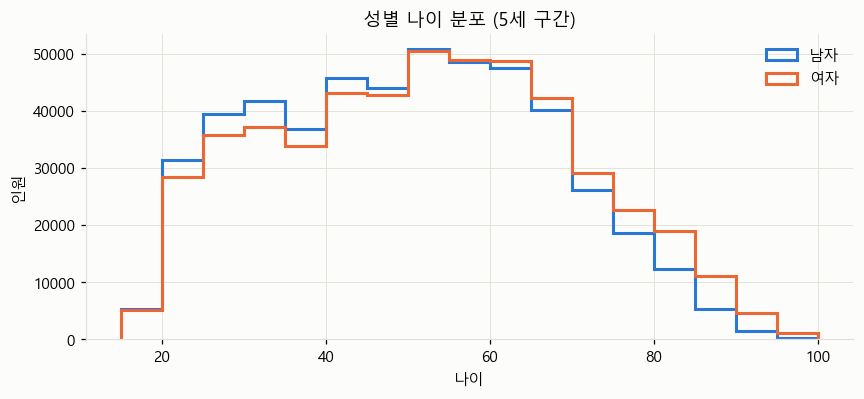

In [6]:
# 나이의 요약 통계. alias()는 결과 컬럼에 이름을 붙인다
print(demo.select(
    pl.col("age").min().alias("최소"),
    pl.col("age").quantile(0.25).alias("1사분위"),
    pl.col("age").median().alias("중앙값"),
    pl.col("age").mean().round(1).alias("평균"),
    pl.col("age").quantile(0.75).alias("3사분위"),
    pl.col("age").max().alias("최대"),
))

bins = range(15, 105, 5)   # 15세부터 5세 간격으로 구간을 나눈다
fig, ax = plt.subplots(figsize=(9, 3.6))
# 성별마다 선을 하나씩 그린다. 막대를 겹치면 가려지므로 테두리만 그리는 step 모양을 쓴다
for sex, color in zip(sorted(demo["sex"].unique()), [C.COLOR_1, C.COLOR_2]):
    ax.hist(demo.filter(pl.col("sex") == sex)["age"], bins=bins, histtype="step", linewidth=2, color=color, label=sex)
ax.set_xlabel("나이")
ax.set_ylabel("인원")
ax.set_title("성별 나이 분포 (5세 구간)")
ax.legend(frameon=False)
plt.show()

### 3-3. 범주형 변수의 분포

`share()`는 한 컬럼의 값별 인원과 비율(%)을 돌려준다. 4절에서도 같은 함수를 쓴다.

In [7]:
# 학력을 낮은 것부터 높은 것 순으로 적어 둔다. 그림의 축 순서와 '전문대 이상' 계산에 쓴다
EDU_ORDER = ["무학", "초등학교", "중학교", "고등학교", "2~3년제 전문대학", "4년제 대학교", "대학원"]


def share(df, col):
    """값별 인원과 비율(%). 많은 순으로 정렬한다."""
    return (
        df.group_by(col).len()                                  # 값별로 묶어 행 수를 센다 (결과 컬럼 이름은 len)
        .with_columns((pl.col("len") / pl.col("len").sum() * 100).round(1).alias("비율(%)"))   # 전체 합으로 나눠 %로
        .rename({"len": "인원"})
        .sort("인원", descending=True)
    )


for col in ["sex", "marital_status", "education_level", "housing_type"]:
    print(f"[{col}]")
    print(share(demo, col))

[sex]
┌──────┬────────┬─────────┐
│ sex  ┆ 인원   ┆ 비율(%) │
│ ---  ┆ ---    ┆ ---     │
│ str  ┆ u32    ┆ f64     │
╞══════╪════════╪═════════╡
│ 여자 ┆ 504442 ┆ 50.4    │
│ 남자 ┆ 495558 ┆ 49.6    │
└──────┴────────┴─────────┘
[marital_status]
┌────────────────┬────────┬─────────┐
│ marital_status ┆ 인원   ┆ 비율(%) │
│ ---            ┆ ---    ┆ ---     │
│ str            ┆ u32    ┆ f64     │
╞════════════════╪════════╪═════════╡
│ 배우자있음     ┆ 592538 ┆ 59.3    │
│ 미혼           ┆ 256962 ┆ 25.7    │
│ 사별           ┆ 87888  ┆ 8.8     │
│ 이혼           ┆ 62612  ┆ 6.3     │
└────────────────┴────────┴─────────┘
[education_level]
┌──────────────────┬────────┬─────────┐
│ education_level  ┆ 인원   ┆ 비율(%) │
│ ---              ┆ ---    ┆ ---     │
│ str              ┆ u32    ┆ f64     │
╞══════════════════╪════════╪═════════╡
│ 고등학교         ┆ 331377 ┆ 33.1    │
│ 4년제 대학교     ┆ 271256 ┆ 27.1    │
│ 2~3년제 전문대학 ┆ 150235 ┆ 15.0    │
│ 중학교           ┆ 85255  ┆ 8.5     │
│ 초등학교         ┆ 81239  ┆ 8.1     │
│ 대학

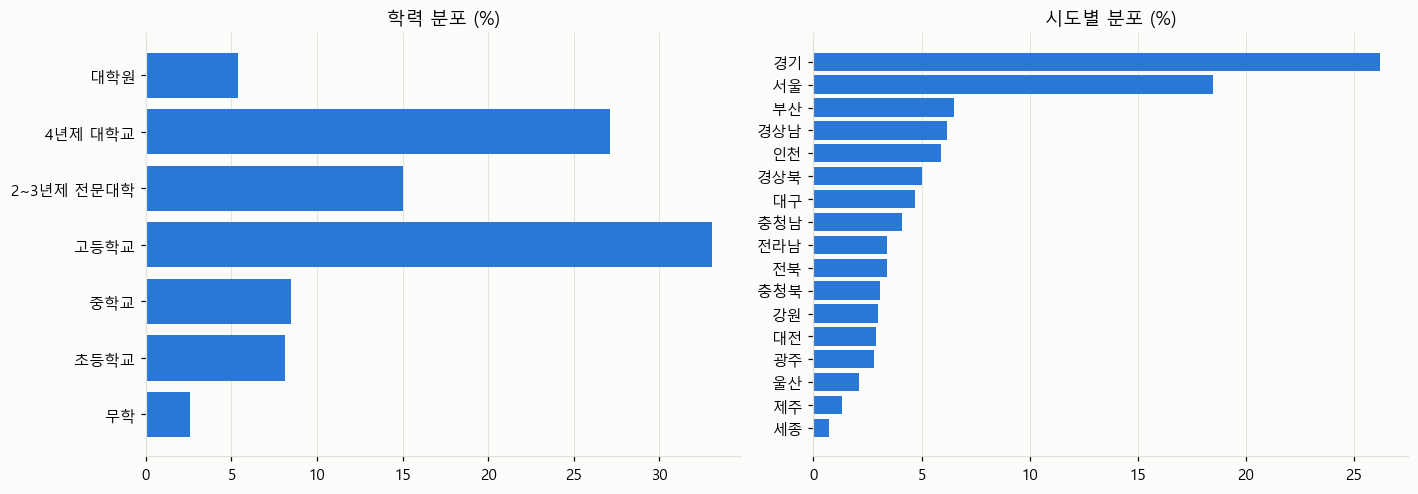

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))   # 그림 두 개를 옆으로 나란히

edu = share(demo, "education_level")
# 학력은 인원순이 아니라 EDU_ORDER 순서로 놓는다. 학력마다 순번(o)을 붙이고 그 순번으로 정렬한다
edu = edu.with_columns(pl.col("education_level").replace_strict({k: i for i, k in enumerate(EDU_ORDER)}, default=-1).alias("o")).sort("o")
axes[0].barh(edu["education_level"], edu["비율(%)"], color=C.COLOR_1)
axes[0].set_title("학력 분포 (%)")

prov = share(demo, "province").sort("인원")   # 가로 막대는 아래에서 위로 쌓이므로 오름차순으로 두면 큰 값이 위에 온다
axes[1].barh(prov["province"], prov["비율(%)"], color=C.COLOR_1)
axes[1].set_title("시도별 분포 (%)")

for ax in axes:
    ax.grid(axis="y", visible=False)   # 가로 막대에서는 세로 눈금선만 남긴다
plt.tight_layout()
plt.show()

### 3-4. 직업

직업은 고유값이 2,000개가 넘는 자유 텍스트에 가깝다. 세 가지를 먼저 알아 둔다.

- **`무직`이 가장 큰 단일 범주다.** 주부, 학생, 은퇴자, 실업자가 구분되지 않는다.
- **`전직 ○○, 현재 구직중`** 꼴의 값이 따로 있다. 예전 직업이 남아 있는 구직자다.
- 나머지가 현재 취업자다.

In [9]:
FORMER_MARK = "현재 구직중"   # '전직 일반 간호사, 현재 구직중' 같은 값을 가려내는 표지
NO_JOB = "무직"

# 직업 값을 보고 세 가지 상태로 나눈 컬럼(work_status)을 붙인다. when-then-otherwise는 if-elif-else와 같다
demo = demo.with_columns(
    pl.when(pl.col("occupation") == NO_JOB).then(pl.lit("무직"))
    .when(pl.col("occupation").str.contains(FORMER_MARK, literal=True)).then(pl.lit("전직(구직중)"))
    .otherwise(pl.lit("취업자"))
    .alias("work_status")
)
print(share(demo, "work_status"))

employed = demo.filter(pl.col("work_status") == "취업자")   # 4절에서 비교 기준으로 쓴다
print(f"직업 고유값: 전체 {demo['occupation'].n_unique():,}개, 취업자만 {employed['occupation'].n_unique():,}개")

# 취업자 가운데 많은 직업 20개. 여기의 비율(%)은 취업자 안에서의 비율이다
share(employed, "occupation").head(20)

┌──────────────┬────────┬─────────┐
│ work_status  ┆ 인원   ┆ 비율(%) │
│ ---          ┆ ---    ┆ ---     │
│ str          ┆ u32    ┆ f64     │
╞══════════════╪════════╪═════════╡
│ 취업자       ┆ 608438 ┆ 60.8    │
│ 무직         ┆ 367349 ┆ 36.7    │
│ 전직(구직중) ┆ 24213  ┆ 2.4     │
└──────────────┴────────┴─────────┘
직업 고유값: 전체 2,120개, 취업자만 1,138개


occupation,인원,비율(%)
str,u32,f64
"""건물 청소원""",18253,3.0
"""건물 경비원""",17473,2.9
"""경리 사무원""",16146,2.7
"""사무 보조원""",13630,2.2
"""전화 상담원""",11211,1.8
"""시설 경비원""",10897,1.8
"""일반 비서""",10895,1.8
"""하역 및 적재 관련 단순 종사원""",9160,1.5
"""한식 조리사""",8566,1.4


## 4. 직무 관점으로 걸러 보기

직업 컬럼은 표준 코드가 아니라 직업명 문자열이다. 그래서 직무를 고르는 일은 **직업명 검색**에서 시작한다.

1. `find_jobs("간호")`로 어떤 직업명이 걸리는지 먼저 본다.
2. 아래 설정값을 정한다.
3. `job_view()`로 그 직무 집단을 뽑아 요약하고, 취업자 전체와 비교하고, 서술문을 읽는다.

### 4-1. 설정: 여기만 고치면 된다

In [10]:
# 직업명에 이 낱말 가운데 하나라도 들어가면 같은 직무로 묶는다. 환경변수로도 줄 수 있다 (쉼표로 구분).
JOB_KEYWORDS = [k.strip() for k in os.environ.get("NPK_JOB_KEYWORDS", "간호").split(",") if k.strip()]

# 걸린 직업명 가운데 빼고 싶은 것. 예: ["간호조무사"]
JOB_EXCLUDE = [k.strip() for k in os.environ.get("NPK_JOB_EXCLUDE", "").split(",") if k.strip()]

# '전직 ○○, 현재 구직중'도 같은 직무로 볼 것인가
INCLUDE_FORMER = os.environ.get("NPK_JOB_INCLUDE_FORMER", "0") == "1"

# 서술문 예시를 몇 명 볼 것인가
N_EXAMPLES = int(os.environ.get("NPK_JOB_N_EXAMPLES", "3"))

print("직무 낱말:", JOB_KEYWORDS, "| 제외:", JOB_EXCLUDE, "| 전직 포함:", INCLUDE_FORMER)

직무 낱말: ['간호'] | 제외: [] | 전직 포함: False


### 4-2. 직업명 검색

In [11]:
def job_expr(keywords, exclude=(), include_former=False):
    """직업명 조건을 polars 식으로 만든다. 낱말은 정규식이 아니라 글자 그대로 찾는다."""
    occ = pl.col("occupation")
    # 낱말마다 '직업명에 들어 있는가'를 따지고, 하나라도 참이면 참으로 본다 (OR)
    hit = pl.any_horizontal([occ.str.contains(k, literal=True) for k in keywords])
    # 제외 낱말이 들어 있는 직업명은 뺀다. ~는 부정(NOT), &는 그리고(AND)
    for k in exclude:
        hit = hit & ~occ.str.contains(k, literal=True)
    # '전직 ○○, 현재 구직중'을 빼는 것이 기본이다
    if not include_former:
        hit = hit & ~occ.str.contains(FORMER_MARK, literal=True)
    return hit   # 아직 계산된 값이 아니라 조건식이다. filter()에 넣을 때 계산된다


def find_jobs(keywords, exclude=(), include_former=True):
    """낱말에 걸리는 직업명과 인원. 직무를 정하기 전에 무엇이 섞여 들어오는지 확인하는 용도다."""
    if isinstance(keywords, str):   # find_jobs("간호")처럼 낱말 하나만 줘도 되게 한다
        keywords = [keywords]
    return share(demo.filter(job_expr(keywords, exclude, include_former)), "occupation")


# 검색 단계에서는 전직도 함께 보여 준다 (include_former=True가 기본). 무엇이 있는지 알고 나서 뺄지 정한다
find_jobs(JOB_KEYWORDS, JOB_EXCLUDE)

occupation,인원,비율(%)
str,u32,f64
"""일반 간호사""",2483,41.9
"""간호조무사""",2261,38.2
"""전문 간호사""",843,14.2
"""전직 일반 간호사, 현재 구직중""",199,3.4
"""전직 간호조무사, 현재 구직중""",121,2.0
"""전직 전문 간호사, 현재 구직중""",15,0.3


낱말 하나에 성격이 다른 직업이 함께 걸리는 일이 흔하다. 예를 들어 `개발`에는 소프트웨어 개발자와 섬유 공정 개발 기술자가 같이 나온다. 이 표를 보고 `JOB_KEYWORDS`를 더 구체적으로 쓰거나 `JOB_EXCLUDE`에 뺄 낱말을 넣은 뒤 4-1부터 다시 실행한다.

### 4-3. 직무 집단 뽑기와 요약

In [12]:
def job_view(keywords, exclude=(), include_former=False, with_text=True):
    """직무 집단의 행을 돌려준다. with_text=True면 서술문 컬럼도 함께 읽는다."""
    if isinstance(keywords, str):
        keywords = [keywords]
    cond = job_expr(keywords, exclude, include_former)
    if not with_text:
        return demo.filter(cond)   # 메모리에 있는 표에서 거르므로 빠르다
    # 서술문이 필요하면 parquet에서 다시 읽는다. 조건에 맞는 행만, 필요한 컬럼만 읽는다
    return lf.filter(cond).select(["uuid"] + DEMO_COLS + TEXT_COLS).collect()


def job_summary(df, label):
    """직무 집단 한 줄 요약."""
    n = df.height   # 행 수
    # 전공은 대학에 가지 않은 사람('해당없음')을 빼고 가장 흔한 것을 찾는다
    top_field = df.filter(pl.col("bachelors_field") != "해당없음")["bachelors_field"].mode()
    return {
        "직무": label,
        "인원": n,
        "전체 대비(%)": round(n / demo.height * 100, 2),
        "취업자 대비(%)": round(n / employed.height * 100, 2),
        "직업명 수": df["occupation"].n_unique(),                    # 이 직무로 묶인 직업명이 몇 가지인가
        "여자(%)": round((df["sex"] == "여자").mean() * 100, 1),      # 참/거짓의 평균이 곧 비율이다
        "나이 중앙값": df["age"].median(),
        "전문대 이상(%)": round(df["education_level"].is_in(EDU_ORDER[4:]).mean() * 100, 1),   # EDU_ORDER[4:] = 전문대, 4년제, 대학원
        "가장 많은 전공": top_field.sort()[0] if len(top_field) else "-",
        "가장 많은 시도": df["province"].mode().sort()[0],
    }


JOB_LABEL = "+".join(JOB_KEYWORDS)   # 표와 그림에 쓸 직무 이름
job = job_view(JOB_KEYWORDS, JOB_EXCLUDE, INCLUDE_FORMER)   # 4절의 나머지 셀은 모두 이 job을 쓴다
if job.height == 0:   # 낱말이 틀렸을 때 뒤에서 엉뚱한 오류가 나지 않도록 여기서 멈춘다
    raise ValueError(f"{JOB_KEYWORDS}에 걸리는 직업이 없다. find_jobs()로 낱말을 확인한다.")

pl.DataFrame([job_summary(job, JOB_LABEL)])

직무,인원,전체 대비(%),취업자 대비(%),직업명 수,여자(%),나이 중앙값,전문대 이상(%),가장 많은 전공,가장 많은 시도
str,i64,f64,f64,i64,f64,f64,f64,str,str
"""간호""",5587,0.56,0.92,3,94.2,44.0,66.1,"""보건·복지""","""서울"""


### 4-4. 취업자 전체와 비교

비교 기준은 전체 100만 명이 아니라 **취업자**(무직과 전직 제외)다. 전체에는 고령 무직자가 많아서, 전체와 비교하면 어떤 직무든 젊고 학력이 높게 나온다.

`차이(%p)`가 양수면 그 값이 이 직무에 취업자 평균보다 많다는 뜻이다.

In [13]:
def compare_share(job_df, col, base=None, top=None):
    """한 컬럼의 분포를 직무 집단과 기준 집단에서 나란히 본다."""
    base = employed if base is None else base   # 기준 집단을 따로 주지 않으면 취업자 전체
    a = share(job_df, col).select(col, pl.col("인원").alias("직무 인원"), pl.col("비율(%)").alias("직무(%)"))
    b = share(base, col).select(col, pl.col("비율(%)").alias("취업자(%)"))
    out = (
        a.join(b, on=col, how="full", coalesce=True)   # 한쪽에만 있는 값도 남긴다 (예: 이 직무에 없는 학력)
        .fill_null(0)                                  # 없는 쪽은 0%로 채운다
        .with_columns((pl.col("직무(%)") - pl.col("취업자(%)")).round(1).alias("차이(%p)"))
        .sort("직무(%)", descending=True)
    )
    return out.head(top) if top else out


# (컬럼, 위에서 몇 줄만 볼지). None이면 전부 보여 준다
for col, top in [("sex", None), ("education_level", None), ("bachelors_field", 8), ("marital_status", None), ("province", 8)]:
    print(f"[{col}]")
    print(compare_share(job, col, top=top))

[sex]
┌──────┬───────────┬─────────┬───────────┬──────────┐
│ sex  ┆ 직무 인원 ┆ 직무(%) ┆ 취업자(%) ┆ 차이(%p) │
│ ---  ┆ ---       ┆ ---     ┆ ---       ┆ ---      │
│ str  ┆ u32       ┆ f64     ┆ f64       ┆ f64      │
╞══════╪═══════════╪═════════╪═══════════╪══════════╡
│ 여자 ┆ 5261      ┆ 94.2    ┆ 44.3      ┆ 49.9     │
│ 남자 ┆ 326       ┆ 5.8     ┆ 55.7      ┆ -49.9    │
└──────┴───────────┴─────────┴───────────┴──────────┘
[education_level]
┌──────────────────┬───────────┬─────────┬───────────┬──────────┐
│ education_level  ┆ 직무 인원 ┆ 직무(%) ┆ 취업자(%) ┆ 차이(%p) │
│ ---              ┆ ---       ┆ ---     ┆ ---       ┆ ---      │
│ str              ┆ u32       ┆ f64     ┆ f64       ┆ f64      │
╞══════════════════╪═══════════╪═════════╪═══════════╪══════════╡
│ 4년제 대학교     ┆ 2400      ┆ 43.0    ┆ 31.0      ┆ 12.0     │
│ 고등학교         ┆ 1888      ┆ 33.8    ┆ 33.6      ┆ 0.2      │
│ 2~3년제 전문대학 ┆ 711       ┆ 12.7    ┆ 17.2      ┆ -4.5     │
│ 대학원           ┆ 583       ┆ 10.4    ┆ 6.3       ┆ 4.1  

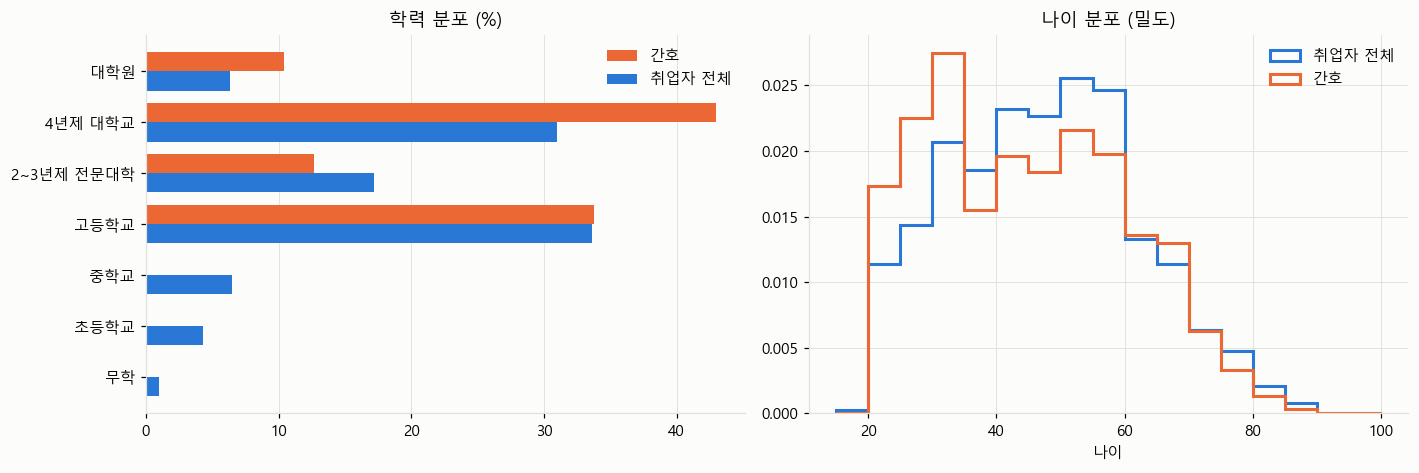

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# 왼쪽: 학력 분포
edu = compare_share(job, "education_level")
edu = edu.with_columns(pl.col("education_level").replace_strict({k: i for i, k in enumerate(EDU_ORDER)}, default=-1).alias("o")).sort("o")
y = range(edu.height)   # 학력마다 세로 위치 0, 1, 2, ...
h = 0.38                # 막대 두께. 두 막대를 위아래로 반 칸씩 비켜 놓는다
axes[0].barh([i + h / 2 for i in y], edu["직무(%)"], height=h, color=C.COLOR_2, label=JOB_LABEL)
axes[0].barh([i - h / 2 for i in y], edu["취업자(%)"], height=h, color=C.COLOR_1, label="취업자 전체")
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(edu["education_level"])
axes[0].set_title("학력 분포 (%)")
axes[0].grid(axis="y", visible=False)
axes[0].legend(frameon=False)

# 오른쪽: 나이 분포 (두 집단의 크기가 다르므로 비율로 그린다)
bins = range(15, 105, 5)
axes[1].hist(employed["age"], bins=bins, density=True, histtype="step", linewidth=2, color=C.COLOR_1, label="취업자 전체")
axes[1].hist(job["age"], bins=bins, density=True, histtype="step", linewidth=2, color=C.COLOR_2, label=JOB_LABEL)
axes[1].set_title("나이 분포 (밀도)")
axes[1].set_xlabel("나이")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

### 4-5. 직무 집단 안에서 나눠 보기

같은 직무 안에서 직업명별로 학력과 나이가 어떻게 다른지 본다. 수준별 직무 페르소나를 만들 때 출발점이 되는 표다.

In [15]:
# 직업명별로 묶어 여러 값을 한꺼번에 계산한다. agg() 안의 식 하나가 결과 컬럼 하나가 된다
(
    job.group_by("occupation")
    .agg(
        pl.len().alias("인원"),
        (pl.col("sex") == "여자").mean().mul(100).round(1).alias("여자(%)"),
        pl.col("age").median().alias("나이 중앙값"),
        pl.col("education_level").is_in(EDU_ORDER[4:]).mean().mul(100).round(1).alias("전문대 이상(%)"),
        (pl.col("education_level") == "대학원").mean().mul(100).round(1).alias("대학원(%)"),
    )
    .sort("인원", descending=True)
)

occupation,인원,여자(%),나이 중앙값,전문대 이상(%),대학원(%)
str,u32,f64,f64,f64,f64
"""일반 간호사""",2483,96.5,34.0,100.0,4.8
"""간호조무사""",2261,89.7,55.0,16.3,0.0
"""전문 간호사""",843,99.1,41.0,100.0,54.9


In [16]:
# 직업명 x 학력 교차표 (행 기준 %)
ct = (
    job.group_by("occupation", "education_level").len()   # (직업명, 학력) 조합별 인원
    # over("occupation"): 합계를 직업명 안에서만 구한다. 그래서 각 행의 비율을 더하면 100이 된다
    .with_columns((pl.col("len") / pl.col("len").sum().over("occupation") * 100).round(1).alias("pct"))
    .pivot(on="education_level", index="occupation", values="pct")   # 학력 값을 컬럼으로 펼친다
    .fill_null(0)                                                    # 한 명도 없는 조합은 0
)
# 컬럼을 학력 순서대로 놓는다. 이 직무에 없는 학력은 건너뛴다
ct.select(["occupation"] + [c for c in EDU_ORDER if c in ct.columns])

occupation,초등학교,중학교,고등학교,2~3년제 전문대학,4년제 대학교,대학원
str,f64,f64,f64,f64,f64,f64
"""일반 간호사""",0.0,0.0,0.0,18.2,77.0,4.8
"""간호조무사""",0.1,0.1,83.5,11.2,5.0,0.0
"""전문 간호사""",0.0,0.0,0.0,0.7,44.4,54.9


### 4-6. 기술 목록에서 자주 나오는 낱말

`skills_and_expertise_list`는 리스트처럼 생긴 문자열이다. 작은따옴표 안의 항목을 꺼내 센다. LLM이 사람마다 다르게 쓴 구절이라 같은 항목이 그대로 반복되는 일은 드물다. 그래서 항목을 다시 띄어쓰기로 쪼갠 낱말 빈도를 함께 본다.

In [17]:
skills = (
    # "['환자 상태 관찰', '의료 행정']" 같은 문자열에서 작은따옴표로 싸인 부분을 모두 찾아 리스트로 만든다
    job.select(pl.col("skills_and_expertise_list").str.extract_all(r"'([^']+)'").alias("s"))
    .explode("s")                                     # 리스트의 항목 하나가 행 하나가 되게 펼친다
    .with_columns(pl.col("s").str.strip_chars("'"))   # 양끝에 남은 작은따옴표를 뗀다
    .drop_nulls()
)
print(f"기술 항목 {skills.height:,}개, 고유 {skills['s'].n_unique():,}개")

words = (
    skills.select(pl.col("s").str.split(" ").alias("w")).explode("w")   # 항목을 띄어쓰기로 쪼개 낱말 하나가 행 하나
    .filter(pl.col("w").str.len_chars() >= 2)                           # '및', '등' 같은 한 글자는 버린다
    .filter(~pl.col("w").is_in(["관리", "기술", "능력", "활용", "통한", "위한"]))   # 어느 직무에나 나오는 낱말
)
share(words, "w").rename({"w": "낱말", "인원": "횟수"}).head(25)

기술 항목 23,108개, 고유 10,167개


낱말,횟수,비율(%)
str,u32,f64
"""환자""",8028,7.8
"""의료""",2342,2.3
"""응급""",2328,2.3
"""모니터링""",2287,2.2
"""상태""",2044,2.0
"""심리""",1930,1.9
"""처치""",1929,1.9
"""보호자""",1880,1.8
"""기록""",1866,1.8


### 4-7. 서술문 읽기

숫자만으로는 데이터가 어떤 모습인지 알기 어렵다. 직무 집단에서 몇 명을 뽑아 직업 페르소나, 기술 목록, 경력 목표를 읽는다. 시드를 고정했으므로 같은 설정이면 같은 사람이 나온다.

In [18]:
def show_examples(df, n=3, seed=C.SEED):
    """df에서 n명을 무작위로 뽑아 인구통계 변수 한 줄과 서술문 세 가지를 찍는다."""
    # 집단이 n명보다 작으면 있는 만큼만 뽑는다. to_dicts()는 행마다 {컬럼: 값} 사전을 만든다
    for r in df.sample(n=min(n, df.height), seed=seed).to_dicts():
        print("=" * 100)
        print(f"{r['occupation']} | {r['sex']} {r['age']}세 | {r['education_level']} ({r['bachelors_field']}) | {r['province']} {r['district']}")
        print("-" * 100)
        print("[직업 페르소나]", r["professional_persona"])
        print("[기술 목록]    ", r["skills_and_expertise_list"])
        print("[경력 목표]    ", r["career_goals_and_ambitions"])


show_examples(job, N_EXAMPLES)

간호조무사 | 여자 62세 | 고등학교 (해당없음) | 서울 서울-용산구
----------------------------------------------------------------------------------------------------
[직업 페르소나] 임영희 씨는 용산의 한 의원에서 수십 년째 환자들의 미세한 낯빛 변화를 읽어내는 베테랑 간호조무사로, 꼼꼼한 행정 처리와 차분한 말씨 덕분에 원장님과 환자들 사이에서 두터운 신뢰를 받는 기둥 같은 존재입니다. 퇴직 후에는 그동안 몸에 익힌 돌봄 기술을 활용해 동네 독거노인들을 위한 소규모 봉사 모임을 직접 운영하며 보람찬 제2의 인생을 설계하고 있습니다.
[기술 목록]     ['환자 상태 관찰 및 응급 상황 초기 대처', '의료 행정 서류 작성 및 관리', '환자 맞춤형 정서 케어 및 상담', '기본 간호 처치 및 드레싱 보조']
[경력 목표]     이제는 매일 반복되는 병원 업무의 긴장감에서 조금 벗어나, 그동안 쌓아온 돌봄의 기술을 지역 사회의 소외된 이웃을 위해 나누는 소규모 봉사 모임을 구상하고 있습니다. 정년 이후의 삶을 단순히 쉬는 시간이 아니라, 그동안 생업 때문에 미뤄두었던 민화 그리기나 서예를 본격적으로 배우는 제2의 학습기로 만들고자 합니다.
전문 간호사 | 여자 52세 | 4년제 대학교 (보건·복지) | 서울 서울-강북구
----------------------------------------------------------------------------------------------------
[직업 페르소나] 문은미 씨는 강북구의 한 대형 병원에서 복합 증상을 보이는 환자들의 우선순위를 빠르게 판단해 처치하는 숙련된 전문 간호사입니다. 문은미 씨는 까다로운 보호자들의 마음을 능숙하게 달래면서도, 서툰 후배 간호사들에게는 실무적인 조언을 아끼지 않는 든든한 멘토 역할을 수행합니다.
[기술 목록]     ['중증 환자 상태 모니터링 및 응급 처치', '보건 복지 행정

조건을 더 걸어서 읽을 수도 있다. 아래는 같은 직무에서 학력이 가장 높은 집단과 낮은 집단을 한 명씩 읽는 예다. 서술문에 숙련도 표현이 학력에 따라 달라지는지 눈으로 확인하는 용도다.

In [19]:
# 이 직무에 실제로 있는 학력만 낮은 순서대로 남긴다
edu_in_job = [e for e in EDU_ORDER if e in job["education_level"].unique().to_list()]
# 맨 뒤(가장 높은 학력)와 맨 앞(가장 낮은 학력)에서 한 명씩 읽는다
for level in (edu_in_job[-1], edu_in_job[0]):
    print(f"\n### 학력: {level}")
    show_examples(job.filter(pl.col("education_level") == level), n=1)


### 학력: 대학원
전문 간호사 | 여자 54세 | 대학원 (보건·복지) | 대전 대전-유성구
----------------------------------------------------------------------------------------------------
[직업 페르소나] 이정숙 씨는 대전의 종합병원 병동에서 근무하며 후배들이 놓치기 쉬운 환자의 미세한 호흡 변화나 안색을 단번에 알아채는 노련한 전문 간호사입니다. 의료 행정 서류를 처리할 때 오타 하나 허용하지 않는 꼼꼼함 덕분에 상사들의 신뢰가 두텁지만, 때로는 지나친 완벽주의 때문에 스스로를 몰아붙여 쉽게 피로해지곤 합니다.
[기술 목록]     ['고위험 환자 집중 모니터링 및 케어', '맞춤형 간호 케어 플랜 수립', '의료 행정 프로세스 최적화', '신입 간호사 임상 지도 및 교육', '환자 보호자 심리 상담 및 중재']
[경력 목표]     현재의 전문성을 유지하면서도, 퇴직 후에는 지역 사회의 소외된 이들을 위한 작은 보건 상담소나 복지 센터에서 힘을 보태는 완만한 삶의 전환을 준비하고 있습니다. 직급의 상승이라는 성취보다는 동료와 환자들에게 끝까지 신뢰받는 숙련된 전문가로 남는 것에 가치를 둡니다.

### 학력: 초등학교
간호조무사 | 여자 53세 | 초등학교 (해당없음) | 경상북 경상북-경산시
----------------------------------------------------------------------------------------------------
[직업 페르소나] 이미영 씨는 경산의 지역 병원에서 수십 년간 잔뼈가 굵은 간호조무사로, 고성이 오가는 대기실에서도 보호자의 손을 꽉 잡으며 상황을 정리하는 능숙함을 보입니다. 다만 업무 효율은 높지만 책상 위 서류 뭉치를 제때 정리하지 못해 가끔 동료들의 핀잔을 듣기도 합니다.
[기술 목록]     ['환자 바이탈 체크 및 기본 간호', '병원 행정 서류 및 접수 관리', '고령 환자 심리 케어 및

### 4-8. 여러 직무를 한 표로 비교

직무 이름과 검색 낱말을 사전으로 주면 한 줄씩 요약해 나란히 놓는다. 낱말은 4-2의 `find_jobs()`로 먼저 확인하고 고른다.

In [20]:
# 직무 이름: {"keywords": 찾을 낱말들, "exclude": 뺄 낱말들(없어도 된다)}
JOB_SETS = {
    "간호": {"keywords": ["간호사"]},   # '간호사'로 찾으면 간호조무사는 빠진다
    "소프트웨어 개발": {"keywords": ["소프트웨어 개발", "프로그래머", "웹 개발"]},
    "교사(초중등)": {"keywords": ["초등학교 교사", "중학교 교사", "고등학교 교사", "중·고등학교 교사"]},
    "경리·회계 사무": {"keywords": ["경리 사무원", "회계 사무원"]},
    "건물 청소·경비": {"keywords": ["건물 청소원", "건물 경비원"]},
}

rows = []
for label, spec in JOB_SETS.items():
    # 요약에는 서술문이 필요 없으므로 with_text=False로 빠르게 거른다
    df = job_view(spec["keywords"], spec.get("exclude", ()), include_former=False, with_text=False)
    if df.height:
        rows.append(job_summary(df, label))
    else:
        print(f"'{label}'에 걸리는 직업이 없다. find_jobs({spec['keywords']})로 확인한다.")

pl.DataFrame(rows)

직무,인원,전체 대비(%),취업자 대비(%),직업명 수,여자(%),나이 중앙값,전문대 이상(%),가장 많은 전공,가장 많은 시도
str,i64,f64,f64,i64,f64,f64,f64,str,str
"""간호""",3326,0.33,0.55,2,97.2,37.0,100.0,"""보건·복지""","""서울"""
"""소프트웨어 개발""",7828,0.78,1.29,10,35.6,41.0,87.5,"""정보통신기술""","""경기"""
"""교사(초중등)""",839,0.08,0.14,2,82.0,42.0,100.0,"""교육""","""경기"""
"""경리·회계 사무""",23396,2.34,3.85,2,47.4,43.0,70.4,"""경영·행정·법""","""경기"""
"""건물 청소·경비""",35726,3.57,5.87,2,55.4,60.0,6.1,"""경영·행정·법""","""경기"""


## 읽을 때 주의할 점

- 이 데이터는 실제 사람이 아니라 **합성 데이터**다. 인구통계 변수는 공식 통계를 따르도록 만들었지만, 직업과 다른 변수의 관계가 실제와 얼마나 맞는지는 따로 검증해야 한다.
- 데이터셋 카드는 세부 직업을 배정할 때 성별·소득·학력·전공이 **각각 독립적으로** 영향을 준다고 가정했다고 밝혔다. 4-5의 교차표에 나오는 직업×학력 조합은 그 가정 아래에서 나온 값이다.
- 직무는 직업명 문자열 검색으로 묶었다. 표준 직업 분류 코드가 없으므로, 분석에 쓰기 전에 `find_jobs()` 결과를 눈으로 확인한다.
- 서술문은 LLM이 썼다. 직무 집단의 기술 목록과 경력 목표는 실제 종사자 조사가 아니라 LLM이 인구통계 변수를 보고 쓴 내용이다.